# causal-learn Tutorial 11: Functional Causal Models: ANM And PNL

Functional causal models use assumptions about the data-generating function, not only assumptions about conditional independence or linear scores. The central idea is simple but powerful: if the true direction is `X -> Y`, then there may be a function `f` such that

$$
Y = f(X) + N_Y
$$

where the noise term `N_Y` is independent of `X`. In the wrong direction, the residuals from predicting `X` from `Y` usually still depend on `Y`. That asymmetry can help orient a pair of variables from observational data.

This notebook focuses on additive noise models (ANM), because the local `causal-learn` install can run ANM directly. It also explains post-nonlinear (PNL) models and includes an optional availability check for `causal-learn`'s PNL implementation, which depends on `torch` in this environment.

Expected runtime: usually under 1-2 minutes. The pairwise ANM screen and bootstrap loop are the slowest parts, but the sample sizes are intentionally small so the notebook remains interactive.

## Learning Goals

By the end of this notebook, you should be able to:

- Explain the functional causal model idea behind ANM and PNL.
- Use `causal-learn`'s `ANM` class to test pairwise causal directions.
- Read ANM p-values as residual-independence diagnostics, not as automatic causal proof.
- Plot fitted functions and residuals in both directions.
- Use bootstrap resampling to check whether a pairwise direction is stable.
- Understand why pairwise ANM is not a complete multivariate graph discovery method.
- Recognize when PNL may be conceptually appropriate and why it is heavier to run.

## Notebook Flow

We start with theory because functional causal models are assumption-driven. Then we set up the environment, create a nonlinear additive-noise pair, run ANM in both directions, inspect residuals, bootstrap the direction decision, stress-test several scenarios, and finally apply pairwise ANM as a screening tool on a small nonlinear DAG.

The last part is especially important: a pairwise direction test can detect direct effects, indirect effects, and confounded associations. That makes it useful as a diagnostic or screening step, but not a replacement for a carefully specified multivariate causal discovery workflow.

## Functional Causal Model Theory

A functional causal model says that each variable is generated by a function of its direct causes plus an independent disturbance term. For a pair of variables, the additive-noise version is:

$$
Y = f(X) + N_Y, \quad N_Y \perp X
$$

The causal claim is not just that `X` predicts `Y`. The stronger claim is that after removing the fitted function `f(X)`, the remaining residual behaves like noise that is independent of `X`.

In the reverse direction, we would ask whether there is another function `g` such that:

$$
X = g(Y) + N_X, \quad N_X \perp Y
$$

For many nonlinear systems, only one of these two directions has independent residuals. ANM uses this asymmetry to choose a more plausible direction.

## Why Nonlinearity Helps Direction

In a purely linear Gaussian relationship, both directions can often explain the same joint distribution. This is why a simple correlation does not tell us whether `X` causes `Y` or `Y` causes `X`.

Nonlinear additive noise changes the geometry. If `Y = sin(X) + noise`, then the forward regression can remove the curved signal and leave residuals that look unrelated to `X`. The reverse regression has to explain `X` as a function of `Y`, but the curve folds information together. Its residuals tend to retain structure, so they remain dependent on `Y`.

That is the intuition behind ANM. It is not a universal truth; it is an identifying assumption that works well for some data-generating systems and poorly for others.

## ANM Versus PNL

ANM assumes the noise is added before observing the outcome:

$$
Y = f(X) + N_Y
$$

A post-nonlinear model allows an additional invertible transformation after the additive-noise mechanism:

$$
Y = g(f(X) + N_Y)
$$

PNL is more flexible because it can represent situations where the observed outcome is a transformed version of an additive-noise latent variable. It is also computationally heavier and harder to fit. In `causal-learn`, the PNL implementation uses neural-network components and requires `torch`.

This notebook keeps ANM as the fully executable core and treats PNL as an important extension to understand.

## What Functional Causal Models Can And Cannot Claim

Functional models can orient some relationships that constraint-based or score-based methods leave ambiguous. But they do not automatically solve hidden confounding, selection bias, measurement error, feedback loops, or omitted common causes.

A high ANM forward p-value and a low backward p-value means: under the fitted regression model and independence test, the forward residuals look more independent than the backward residuals. That is evidence for a direction under the ANM assumptions. It is not, by itself, a final causal proof.

This notebook therefore pairs ANM output with visual checks, scenario stress tests, bootstrap stability, and explicit caveats about pairwise screening.

## Setup

This cell imports the scientific Python stack, the ANM implementation from `causal-learn`, and optional PNL support if the environment has `torch`. It also creates stable output folders and records package versions for reproducibility.

In [1]:
from pathlib import Path
from importlib.metadata import PackageNotFoundError, version
import itertools
import os
import time
import warnings

# Resolve paths before importing matplotlib so the cache directory stays writable.
CWD = Path.cwd()
if CWD.name == "causal_learn" and (CWD / "outputs").exists():
    NOTEBOOK_DIR = CWD
else:
    NOTEBOOK_DIR = (CWD / "notebooks" / "tutorials" / "causal_learn").resolve()

OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
REPORT_DIR = OUTPUT_DIR / "reports"
for directory in [OUTPUT_DIR, DATASET_DIR, TABLE_DIR, FIGURE_DIR, REPORT_DIR, OUTPUT_DIR / "matplotlib_cache"]:
    directory.mkdir(parents=True, exist_ok=True)

os.environ.setdefault("MPLCONFIGDIR", str(OUTPUT_DIR / "matplotlib_cache"))
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from sklearn.exceptions import ConvergenceWarning

from causallearn.search.FCMBased.ANM.ANM import ANM

warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", message="The optimal value found for dimension.*")
warnings.filterwarnings("ignore", message="Predicted variances smaller than 0.*")

try:
    from causallearn.search.FCMBased.PNL.PNL import PNL
    PNL_AVAILABLE = True
    PNL_IMPORT_MESSAGE = "PNL is available."
except ModuleNotFoundError as exc:
    PNL = None
    PNL_AVAILABLE = False
    PNL_IMPORT_MESSAGE = f"PNL is unavailable because an optional dependency is missing: {exc}"

NOTEBOOK_PREFIX = "11"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.facecolor"] = "white"

packages = ["causal-learn", "numpy", "pandas", "scikit-learn", "matplotlib", "seaborn", "torch"]
version_rows = []
for package in packages:
    try:
        package_version = version(package)
    except PackageNotFoundError:
        package_version = "not installed"
    version_rows.append({"package": package, "version": package_version})

package_versions = pd.DataFrame(version_rows)
package_versions.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_package_versions.csv", index=False)

pnl_status = pd.DataFrame(
    [
        {
            "component": "causal-learn PNL",
            "available": PNL_AVAILABLE,
            "message": PNL_IMPORT_MESSAGE,
        }
    ]
)
pnl_status.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pnl_availability.csv", index=False)

display(package_versions)
display(pnl_status)

,package,version
0,causal-learn,0.1.4.5
1,numpy,2.4.4
2,pandas,3.0.2
3,scikit-learn,1.6.1
4,matplotlib,3.10.9
5,seaborn,0.13.2
6,torch,not installed


,component,available,message
0,causal-learn PNL,False,PNL is unavailable because an optional depende...


The setup confirms that ANM is runnable and that PNL is optional in this environment. Since `torch` is not installed here, the PNL section later will explain the workflow and skip execution cleanly instead of failing the notebook.

## Concept Map

This table separates the main objects used in the notebook: the structural function, residuals, independence test, direction rule, and the difference between pairwise and multivariate use.

In [2]:
concept_map = pd.DataFrame(
    [
        {
            "concept": "additive noise model",
            "meaning": "The effect is generated as a function of the cause plus an independent error term.",
            "practical_note": "ANM searches for the direction where residuals look independent of the proposed cause.",
        },
        {
            "concept": "residual independence",
            "meaning": "After fitting the causal function, leftover noise should not depend on the cause.",
            "practical_note": "This is stronger than low prediction error; a good predictor can still leave dependent residuals.",
        },
        {
            "concept": "KCI test",
            "meaning": "Kernel-based conditional independence machinery used here for unconditional residual independence.",
            "practical_note": "The returned p-values are diagnostics under the fitted model, not universal causal probabilities.",
        },
        {
            "concept": "post-nonlinear model",
            "meaning": "The additive-noise mechanism is followed by an invertible nonlinear transformation.",
            "practical_note": "More flexible than ANM, but computationally heavier and dependency-sensitive.",
        },
        {
            "concept": "pairwise screening",
            "meaning": "Running direction tests on pairs of variables from a larger dataset.",
            "practical_note": "Useful for hints, but it can confuse direct effects, indirect paths, and common causes.",
        },
    ]
)
concept_map.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_functional_model_concept_map.csv", index=False)
display(concept_map)

,concept,meaning,practical_note
0,additive noise model,The effect is generated as a function of the c...,ANM searches for the direction where residuals...
1,residual independence,"After fitting the causal function, leftover no...",This is stronger than low prediction error; a ...
2,KCI test,Kernel-based conditional independence machiner...,The returned p-values are diagnostics under th...
3,post-nonlinear model,The additive-noise mechanism is followed by an...,"More flexible than ANM, but computationally he..."
4,pairwise screening,Running direction tests on pairs of variables ...,"Useful for hints, but it can confuse direct ef..."


The key distinction is between prediction and causal direction. ANM is not asking only whether one variable predicts another; it asks whether the residual pattern is compatible with an additive-noise causal mechanism.

## Helper Functions

The helpers below keep the tutorial readable. They standardize pairwise data shape, run ANM in both directions, convert p-values into a direction decision, fit residuals for plotting, and draw small DAG-style figures in the same visual language as the rest of the tutorial series.

In [3]:
def as_column(values):
    """Return values as a two-dimensional column array expected by causal-learn ANM."""
    return np.asarray(values).reshape(-1, 1)


def run_anm_pair(data_x, data_y, x_name="x", y_name="y"):
    """Run causal-learn ANM in both directions and return a tidy result row."""
    start = time.perf_counter()
    p_forward, p_backward = ANM().cause_or_effect(as_column(data_x), as_column(data_y))
    elapsed = time.perf_counter() - start
    p_forward = float(p_forward)
    p_backward = float(p_backward)

    if p_forward > p_backward:
        preferred_direction = f"{x_name} -> {y_name}"
        preferred_source = x_name
        preferred_target = y_name
    else:
        preferred_direction = f"{y_name} -> {x_name}"
        preferred_source = y_name
        preferred_target = x_name

    return {
        "x": x_name,
        "y": y_name,
        "p_value_x_to_y": p_forward,
        "p_value_y_to_x": p_backward,
        "preferred_direction": preferred_direction,
        "preferred_source": preferred_source,
        "preferred_target": preferred_target,
        "p_value_margin": abs(p_forward - p_backward),
        "elapsed_seconds": elapsed,
    }


def fit_anm_residuals(data_x, data_y):
    """Fit GP regressions in both directions and return fitted values plus residuals."""
    model = ANM()
    x_col = as_column(data_x)
    y_col = as_column(data_y)
    y_hat = model.fit_gp(x_col, y_col)
    x_hat = model.fit_gp(y_col, x_col)
    return {
        "y_hat_from_x": y_hat.ravel(),
        "residual_y_from_x": (y_col - y_hat).ravel(),
        "x_hat_from_y": x_hat.ravel(),
        "residual_x_from_y": (x_col - x_hat).ravel(),
    }


def direction_label(row):
    """Create a compact text label for result tables."""
    return f"{row['preferred_direction']} (margin={row['p_value_margin']:.3f})"


def edge_table_from_pairs(pair_table, run_label, min_margin=0.10):
    """Convert pairwise ANM decisions into a graph edge table after a margin filter."""
    filtered = pair_table[pair_table["p_value_margin"] >= min_margin].copy()
    edge_table = filtered.rename(columns={"preferred_source": "source", "preferred_target": "target"})
    edge_table["run"] = run_label
    edge_table["edge_type"] = "-->"
    return edge_table[["run", "source", "edge_type", "target", "p_value_margin", "p_value_x_to_y", "p_value_y_to_x"]]


def directed_pairs(edge_df):
    """Extract directed source-target pairs from a tidy edge table."""
    return set(zip(edge_df["source"], edge_df["target"])) if not edge_df.empty else set()


def summarize_pairwise_screen(edge_df, truth_df, label):
    """Summarize pairwise screen output against direct truth edges."""
    learned_directed = directed_pairs(edge_df)
    true_directed = set(zip(truth_df["source"], truth_df["target"]))
    true_skeleton = {frozenset(edge) for edge in true_directed}
    learned_skeleton = {frozenset(edge) for edge in learned_directed}
    correct_directed = learned_directed & true_directed
    reversed_true = {(src, dst) for src, dst in true_directed if (dst, src) in learned_directed}
    indirect_or_extra = learned_skeleton - true_skeleton
    return pd.DataFrame(
        [
            {
                "run": label,
                "reported_edges": len(edge_df),
                "true_direct_edges": len(true_directed),
                "correct_direct_edges": len(correct_directed),
                "reversed_true_edges": len(reversed_true),
                "missing_true_adjacencies": len(true_skeleton - learned_skeleton),
                "indirect_or_extra_adjacencies": len(indirect_or_extra),
            }
        ]
    )


GRAPH_POSITIONS = {
    "need": (0.11, 0.72),
    "intent": (0.11, 0.28),
    "match": (0.39, 0.50),
    "engagement": (0.62, 0.50),
    "renewal": (0.89, 0.72),
    "support": (0.89, 0.28),
}
NODE_LABELS = {name: name.title() for name in GRAPH_POSITIONS}
NODE_COLORS = {
    "need": "#e0f2fe",
    "intent": "#dbeafe",
    "match": "#ecfccb",
    "engagement": "#fef3c7",
    "renewal": "#fee2e2",
    "support": "#f3e8ff",
}


def trim_edge_to_box(start, end, box_w=0.145, box_h=0.095, gap=0.012):
    """Return edge endpoints that stop just outside source and target boxes."""
    x0, y0 = start
    x1, y1 = end
    dx = x1 - x0
    dy = y1 - y0
    length = float(np.hypot(dx, dy))
    if length == 0:
        return start, end
    effective_w = box_w + 0.04
    effective_h = box_h + 0.04
    x_limit = (effective_w / 2) / abs(dx) if dx else np.inf
    y_limit = (effective_h / 2) / abs(dy) if dy else np.inf
    t = min(x_limit, y_limit) + gap / length
    return (x0 + dx * t, y0 + dy * t), (x1 - dx * t, y1 - dy * t)


def draw_box_graph(edge_df, title, path, note=None):
    """Draw a small DAG-style graph with rounded boxes and visible arrowheads."""
    fig, ax = plt.subplots(figsize=(12, 6.2))
    ax.set_axis_off()
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(0.04, 0.96)
    box_w, box_h = 0.145, 0.095

    for row in edge_df.itertuples(index=False):
        if row.source not in GRAPH_POSITIONS or row.target not in GRAPH_POSITIONS:
            continue
        start_raw = GRAPH_POSITIONS[row.source]
        end_raw = GRAPH_POSITIONS[row.target]
        start, end = trim_edge_to_box(start_raw, end_raw, box_w=box_w, box_h=box_h)
        arrow = FancyArrowPatch(
            start,
            end,
            arrowstyle="-|>",
            mutation_scale=18,
            linewidth=1.8,
            color="#334155",
            connectionstyle="arc3,rad=0.035",
            zorder=2,
        )
        ax.add_patch(arrow)

    for node, (x, y) in GRAPH_POSITIONS.items():
        rect = FancyBboxPatch(
            (x - box_w / 2, y - box_h / 2),
            box_w,
            box_h,
            boxstyle="round,pad=0.018",
            facecolor=NODE_COLORS[node],
            edgecolor="#1f2937",
            linewidth=1.1,
            zorder=5,
        )
        ax.add_patch(rect)
        ax.text(x, y, NODE_LABELS[node], ha="center", va="center", fontsize=10.5, fontweight="bold", zorder=6)

    if note:
        ax.text(0.50, 0.08, note, ha="center", va="center", fontsize=10, color="#475569")
    ax.set_title(title, pad=18, fontsize=14, fontweight="bold")
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()

These helpers make the notebook outputs consistent. The margin rule is intentionally simple: it looks at how different the two residual-independence p-values are. In real work, margin thresholds should be justified with stability checks and domain knowledge.

## Build A Pairwise Additive-Noise Example

The first executable example is a clean nonlinear ANM pair. We generate `x` from a uniform distribution and then generate `y` as a curved function of `x` plus independent noise:

$$
y = \sin(1.6x) + 0.25x^2 + \epsilon
$$

Because the data is generated exactly in the `x -> y` additive-noise direction, ANM should prefer `x -> y` over `y -> x`.

In [4]:
rng = np.random.default_rng(11)
PAIR_N = 300
x = rng.uniform(-2.5, 2.5, size=PAIR_N)
y = np.sin(1.6 * x) + 0.25 * x**2 + rng.normal(0, 0.28, size=PAIR_N)

pair_df = pd.DataFrame({"x": x, "y": y})
pair_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_pairwise_additive_noise.csv", index=False)

pair_summary = pair_df.agg(["mean", "std", "min", "max"]).T.reset_index().rename(columns={"index": "variable"})
pair_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pairwise_data_summary.csv", index=False)

display(pair_summary.round(4))
display(pair_df.head())

,variable,mean,std,min,max
0,x,-0.1094,1.4545,-2.4427,2.4940
1,y,0.5330,0.8416,-1.5523,2.6455


,x,y
0,-1.857149,0.558062
1,-0.003611,0.072225
2,0.507492,0.603599
3,-2.356555,2.053875
4,-1.760370,0.013659


The generated data has one cause and one effect. This is the setting where ANM is easiest to teach because there are no omitted variables inside the synthetic pair.

## Visualize The Nonlinear Pair

Before running ANM, we look at the relationship. The curve matters: nonlinear shape is one of the reasons the forward and reverse residual patterns can become asymmetric.

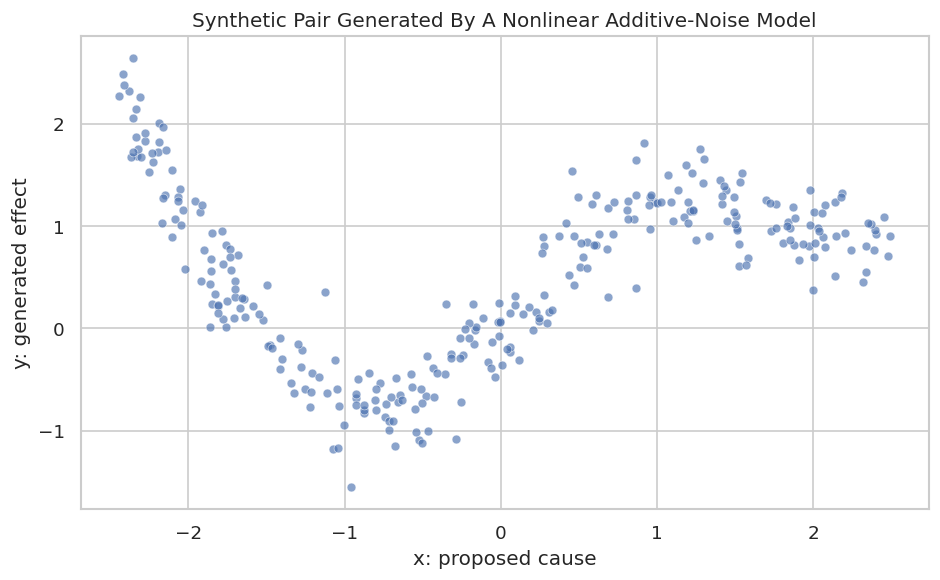

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=pair_df, x="x", y="y", s=28, alpha=0.65, ax=ax)
ax.set_title("Synthetic Pair Generated By A Nonlinear Additive-Noise Model")
ax.set_xlabel("x: proposed cause")
ax.set_ylabel("y: generated effect")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_pairwise_additive_noise_scatter.png", dpi=160, bbox_inches="tight")
plt.show()

The scatter plot shows a curved relationship rather than a simple straight line. ANM will now ask whether the residuals are more independent in the forward direction or the reverse direction.

## Run ANM In Both Directions

`causal-learn`'s `ANM().cause_or_effect(x, y)` fits a Gaussian-process regression in each direction and then applies a kernel independence test between the proposed cause and the fitted residuals. The direction with the larger residual-independence p-value is the more plausible ANM direction.

In [6]:
pair_anm_result = pd.DataFrame([run_anm_pair(pair_df["x"], pair_df["y"], x_name="x", y_name="y")])
pair_anm_result["decision_label"] = pair_anm_result.apply(direction_label, axis=1)
pair_anm_result.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pairwise_anm_direction_result.csv", index=False)
display(pair_anm_result.round(6))

,x,y,p_value_x_to_y,p_value_y_to_x,preferred_direction,preferred_source,preferred_target,p_value_margin,elapsed_seconds,decision_label
0,x,y,0.663914,0.0,x -> y,x,y,0.663914,0.206137,x -> y (margin=0.664)


The forward p-value should be much larger than the backward p-value. That pattern says the residuals from `y ~ f(x)` look more independent of `x` than the residuals from `x ~ g(y)` look independent of `y`.

## Inspect Fitted Functions And Residuals

A p-value table is compact, but residual plots are often more intuitive. This cell fits both directions and visualizes the fitted curves plus residual-vs-input plots.

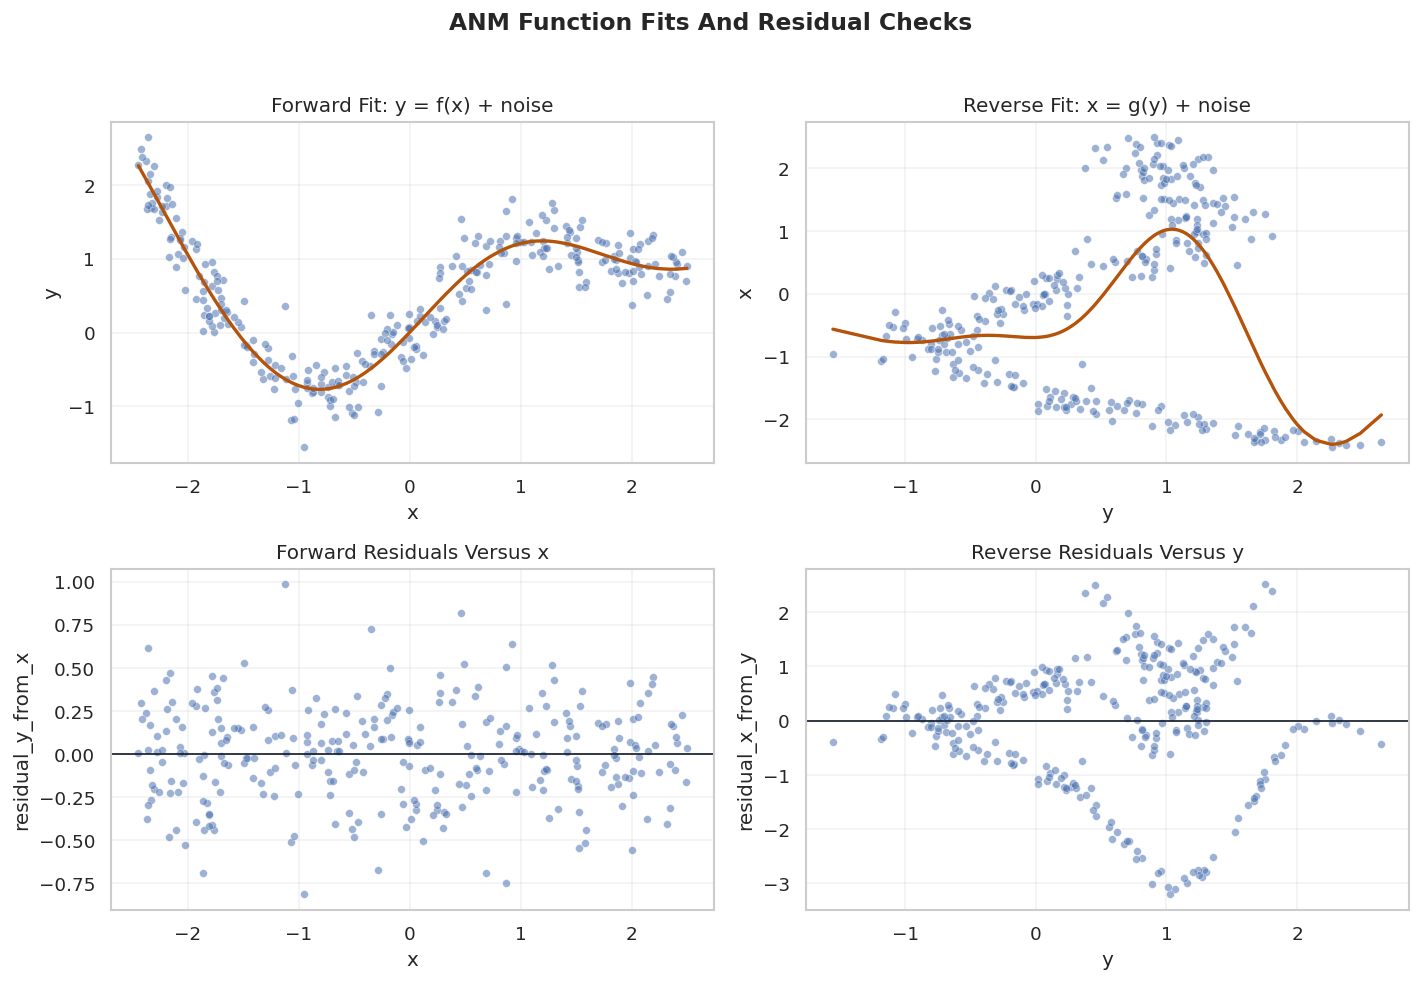

In [7]:
residuals = fit_anm_residuals(pair_df["x"], pair_df["y"])
residual_plot_df = pair_df.assign(
    y_hat_from_x=residuals["y_hat_from_x"],
    residual_y_from_x=residuals["residual_y_from_x"],
    x_hat_from_y=residuals["x_hat_from_y"],
    residual_x_from_y=residuals["residual_x_from_y"],
)
residual_plot_df.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pairwise_residuals.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.scatterplot(data=residual_plot_df, x="x", y="y", s=22, alpha=0.55, ax=axes[0, 0])
sorted_forward = residual_plot_df.sort_values("x")
axes[0, 0].plot(sorted_forward["x"], sorted_forward["y_hat_from_x"], color="#b45309", linewidth=2)
axes[0, 0].set_title("Forward Fit: y = f(x) + noise")

sns.scatterplot(data=residual_plot_df, x="x", y="residual_y_from_x", s=22, alpha=0.55, ax=axes[1, 0])
axes[1, 0].axhline(0, color="#111827", linewidth=1)
axes[1, 0].set_title("Forward Residuals Versus x")

sns.scatterplot(data=residual_plot_df, x="y", y="x", s=22, alpha=0.55, ax=axes[0, 1])
sorted_backward = residual_plot_df.sort_values("y")
axes[0, 1].plot(sorted_backward["y"], sorted_backward["x_hat_from_y"], color="#b45309", linewidth=2)
axes[0, 1].set_title("Reverse Fit: x = g(y) + noise")

sns.scatterplot(data=residual_plot_df, x="y", y="residual_x_from_y", s=22, alpha=0.55, ax=axes[1, 1])
axes[1, 1].axhline(0, color="#111827", linewidth=1)
axes[1, 1].set_title("Reverse Residuals Versus y")

for ax in axes.flat:
    ax.grid(True, alpha=0.25)

fig.suptitle("ANM Function Fits And Residual Checks", y=1.02, fontsize=14, fontweight="bold")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_pairwise_anm_residual_diagnostics.png", dpi=160, bbox_inches="tight")
plt.show()

The forward residual plot should look less structured than the reverse residual plot. That visual pattern is the same idea expressed numerically by the residual-independence p-values.

## Bootstrap Direction Stability

A single ANM run can be sensitive to sample composition. This cell resamples rows, reruns the pairwise direction test, and tracks how often the preferred direction remains `x -> y`.

In [8]:
BOOTSTRAP_RUNS = 25
bootstrap_rows = []
for run_id in range(BOOTSTRAP_RUNS):
    sample_idx = rng.choice(pair_df.index, size=len(pair_df), replace=True)
    sample = pair_df.loc[sample_idx].reset_index(drop=True)
    result = run_anm_pair(sample["x"], sample["y"], x_name="x", y_name="y")
    result["bootstrap_run"] = run_id
    bootstrap_rows.append(result)

bootstrap_results = pd.DataFrame(bootstrap_rows)
bootstrap_results["selected_true_direction"] = bootstrap_results["preferred_direction"].eq("x -> y")
bootstrap_summary = pd.DataFrame(
    [
        {
            "bootstrap_runs": BOOTSTRAP_RUNS,
            "true_direction_selection_rate": bootstrap_results["selected_true_direction"].mean(),
            "median_margin": bootstrap_results["p_value_margin"].median(),
            "min_margin": bootstrap_results["p_value_margin"].min(),
        }
    ]
)

bootstrap_results.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pairwise_bootstrap_results.csv", index=False)
bootstrap_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pairwise_bootstrap_summary.csv", index=False)

display(bootstrap_summary.round(4))
display(bootstrap_results.head().round(6))

,bootstrap_runs,true_direction_selection_rate,median_margin,min_margin
0,25,1.0,0.0228,0.0001


,x,y,p_value_x_to_y,p_value_y_to_x,preferred_direction,preferred_source,preferred_target,p_value_margin,elapsed_seconds,bootstrap_run,selected_true_direction
0,x,y,0.003500,0.0,x -> y,x,y,0.003500,0.209774,0,True
1,x,y,0.004734,0.0,x -> y,x,y,0.004734,0.195841,1,True
2,x,y,0.093825,0.0,x -> y,x,y,0.093825,0.198911,2,True
3,x,y,0.053142,0.0,x -> y,x,y,0.053142,0.203398,3,True
4,x,y,0.894033,0.0,x -> y,x,y,0.894033,0.202067,4,True


A high selection rate means the direction is not just an accident of one sample. If bootstrap decisions were split, the responsible thing would be to report the pair as unstable rather than forcing a direction.

## Plot Bootstrap P-Values

The bootstrap table is precise, but the distribution of p-values makes stability easier to scan. The forward p-values should generally sit above the backward p-values for this synthetic ANM example.

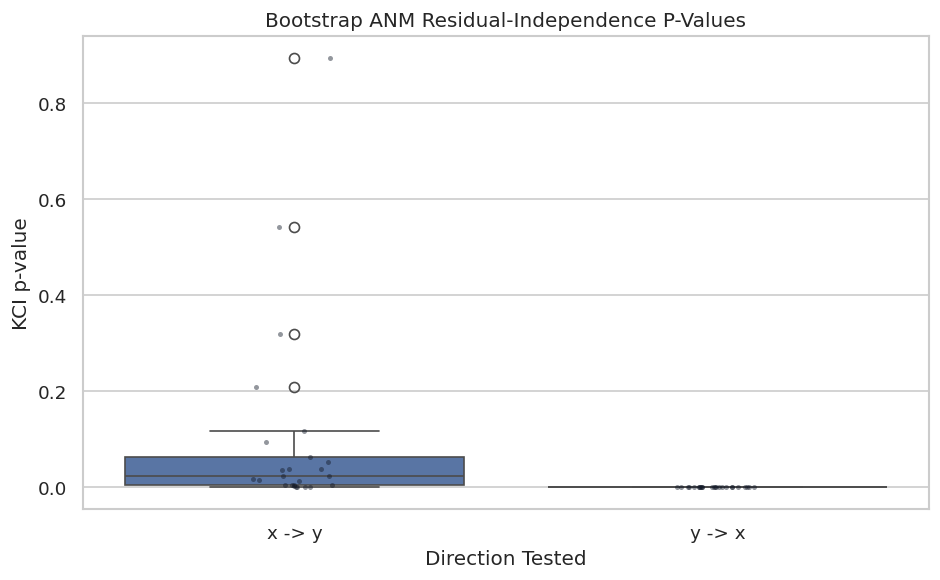

In [9]:
bootstrap_plot_df = bootstrap_results.melt(
    id_vars=["bootstrap_run", "preferred_direction", "selected_true_direction"],
    value_vars=["p_value_x_to_y", "p_value_y_to_x"],
    var_name="direction_test",
    value_name="p_value",
)
bootstrap_plot_df["direction_test"] = bootstrap_plot_df["direction_test"].map(
    {"p_value_x_to_y": "x -> y", "p_value_y_to_x": "y -> x"}
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=bootstrap_plot_df, x="direction_test", y="p_value", ax=ax)
sns.stripplot(data=bootstrap_plot_df, x="direction_test", y="p_value", color="#111827", alpha=0.45, size=3, ax=ax)
ax.set_title("Bootstrap ANM Residual-Independence P-Values")
ax.set_xlabel("Direction Tested")
ax.set_ylabel("KCI p-value")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_pairwise_bootstrap_p_values.png", dpi=160, bbox_inches="tight")
plt.show()

The spread matters as much as the median. A robust ANM direction should show separation across resamples, not just in the original dataset.

## Scenario Stress Tests

Now we compare ANM behavior across several pairwise scenarios. This is where the caveats become concrete:

- Nonlinear additive noise should favor the true direction.
- Linear Gaussian data may be ambiguous or misleading.
- Linear non-Gaussian data can sometimes orient, but LiNGAM is usually a more natural tool there.
- Post-nonlinear data may still have a signal, but strict ANM is misspecified.
- Confounded pairs can produce direction-like output even without a direct causal edge.

In [10]:
def make_pair_scenario(scenario, n_samples=300, seed=0):
    """Generate pairwise data for ANM stress tests."""
    local_rng = np.random.default_rng(seed)
    if scenario == "nonlinear_additive":
        x_vals = local_rng.uniform(-2.5, 2.5, size=n_samples)
        y_vals = np.sin(1.6 * x_vals) + 0.25 * x_vals**2 + local_rng.normal(0, 0.28, size=n_samples)
        true_relation = "x -> y"
    elif scenario == "linear_gaussian":
        x_vals = local_rng.normal(size=n_samples)
        y_vals = 1.15 * x_vals + local_rng.normal(0, 0.75, size=n_samples)
        true_relation = "x -> y, but ANM direction is weakly identified"
    elif scenario == "linear_nongaussian":
        x_vals = local_rng.laplace(size=n_samples)
        y_vals = 1.15 * x_vals + local_rng.laplace(0, 0.65, size=n_samples)
        true_relation = "x -> y, but LiNGAM is the more targeted model"
    elif scenario == "post_nonlinear":
        x_vals = local_rng.uniform(-2.0, 2.0, size=n_samples)
        latent = np.sin(1.4 * x_vals) + local_rng.normal(0, 0.30, size=n_samples)
        y_vals = np.tanh(latent)
        true_relation = "x -> y through post-nonlinear transform"
    elif scenario == "shared_confounder":
        z_vals = local_rng.normal(size=n_samples)
        x_vals = np.sin(z_vals) + local_rng.normal(0, 0.35, size=n_samples)
        y_vals = z_vals**2 + local_rng.normal(0, 0.35, size=n_samples)
        true_relation = "no direct x-y edge; shared hidden z"
    else:
        raise ValueError(f"Unknown scenario: {scenario}")
    return pd.DataFrame({"scenario": scenario, "x": x_vals, "y": y_vals, "true_relation": true_relation})

scenario_names = ["nonlinear_additive", "linear_gaussian", "linear_nongaussian", "post_nonlinear", "shared_confounder"]
scenario_data = pd.concat(
    [make_pair_scenario(name, n_samples=300, seed=100 + i) for i, name in enumerate(scenario_names)],
    ignore_index=True,
)
scenario_results = []
for scenario_name, scenario_df in scenario_data.groupby("scenario"):
    result = run_anm_pair(scenario_df["x"], scenario_df["y"], x_name="x", y_name="y")
    result["scenario"] = scenario_name
    result["true_relation"] = scenario_df["true_relation"].iloc[0]
    scenario_results.append(result)

scenario_results = pd.DataFrame(scenario_results).sort_values("scenario")
scenario_data.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_pairwise_scenario_data.csv", index=False)
scenario_results.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pairwise_scenario_results.csv", index=False)
display(scenario_results[["scenario", "true_relation", "p_value_x_to_y", "p_value_y_to_x", "preferred_direction", "p_value_margin"]].round(6))

,scenario,true_relation,p_value_x_to_y,p_value_y_to_x,preferred_direction,p_value_margin
0,linear_gaussian,"x -> y, but ANM direction is weakly identified",0.503218,0.742556,y -> x,0.239338
1,linear_nongaussian,"x -> y, but LiNGAM is the more targeted model",0.782244,0.000002,x -> y,0.782243
2,nonlinear_additive,x -> y,0.851571,0.000000,x -> y,0.851571
3,post_nonlinear,x -> y through post-nonlinear transform,0.000001,0.000037,y -> x,0.000036
4,shared_confounder,no direct x-y edge; shared hidden z,0.000000,0.000000,x -> y,0.000000


The stress table is a useful antidote to overconfidence. ANM behaves best when its assumptions match the data, and it can produce confident-looking directions in settings where the pairwise causal story is incomplete.

## Plot Scenario Results

This plot compares the two direction-test p-values across the stress scenarios. It is easier to see which scenarios have clear separation and which ones are ambiguous or assumption-sensitive.

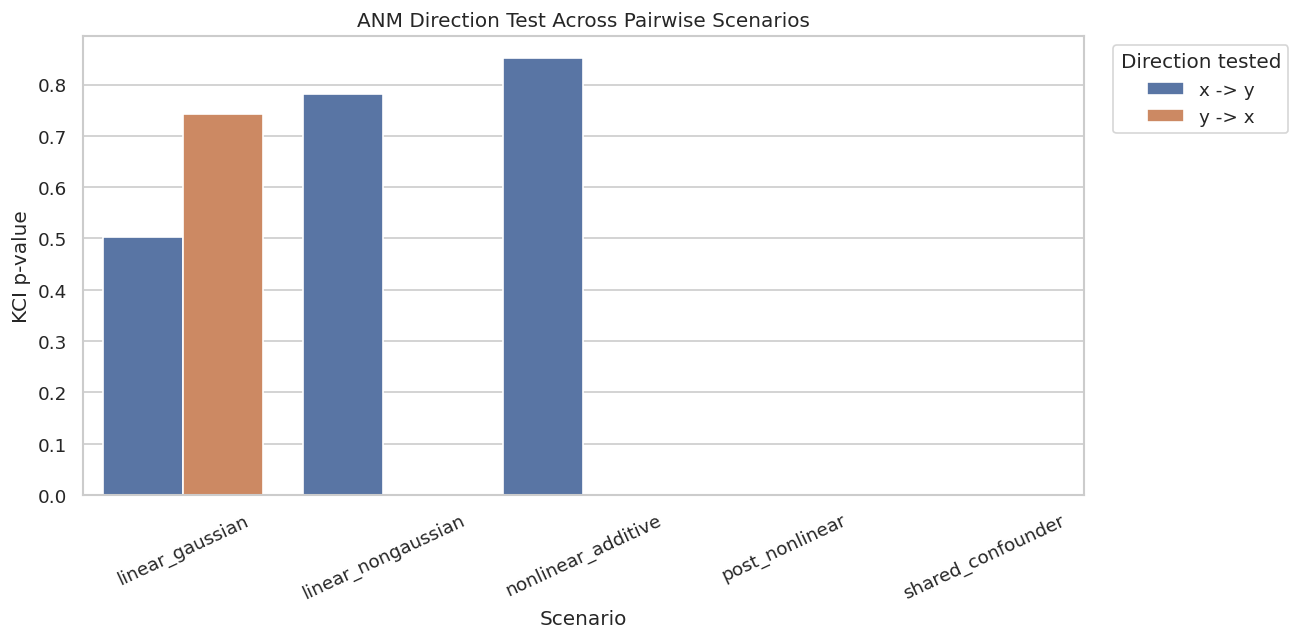

In [11]:
scenario_plot_df = scenario_results.melt(
    id_vars=["scenario", "true_relation", "preferred_direction"],
    value_vars=["p_value_x_to_y", "p_value_y_to_x"],
    var_name="direction_test",
    value_name="p_value",
)
scenario_plot_df["direction_test"] = scenario_plot_df["direction_test"].map(
    {"p_value_x_to_y": "x -> y", "p_value_y_to_x": "y -> x"}
)

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(data=scenario_plot_df, x="scenario", y="p_value", hue="direction_test", ax=ax)
ax.set_title("ANM Direction Test Across Pairwise Scenarios")
ax.set_xlabel("Scenario")
ax.set_ylabel("KCI p-value")
ax.tick_params(axis="x", rotation=25)
ax.legend(title="Direction tested", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_pairwise_scenario_p_values.png", dpi=160, bbox_inches="tight")
plt.show()

Clear p-value separation is most meaningful when the scenario itself matches ANM assumptions. In the confounded scenario, any preferred direction should be treated as a warning sign that pairwise testing is seeing association, not necessarily a direct edge.

## Optional PNL Availability Check

PNL is conceptually important because it handles mechanisms like `Y = g(f(X) + noise)`. The local `causal-learn` PNL implementation depends on `torch`, and this environment does not currently have `torch` installed. This guarded cell shows how the call would be made if the dependency is available.

In [12]:
if PNL_AVAILABLE:
    # Keep epochs low for a tutorial run. Larger values are more appropriate for serious use.
    pnl_model = PNL(epochs=200)
    pnl_forward, pnl_backward = pnl_model.cause_or_effect(as_column(pair_df["x"]), as_column(pair_df["y"]))
    pnl_demo_result = pd.DataFrame(
        [
            {
                "pnl_available": True,
                "p_value_x_to_y": float(pnl_forward),
                "p_value_y_to_x": float(pnl_backward),
                "note": "PNL executed with a small tutorial epoch count.",
            }
        ]
    )
else:
    pnl_demo_result = pd.DataFrame(
        [
            {
                "pnl_available": False,
                "p_value_x_to_y": np.nan,
                "p_value_y_to_x": np.nan,
                "note": PNL_IMPORT_MESSAGE,
            }
        ]
    )

pnl_demo_result.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pnl_guarded_demo_result.csv", index=False)
display(pnl_demo_result)

,pnl_available,p_value_x_to_y,p_value_y_to_x,note
0,False,NaN,NaN,PNL is unavailable because an optional depende...


The important habit is that optional heavy dependencies should be handled explicitly. The notebook remains executable while still teaching what PNL is and how it would fit into the workflow.

## Build A Small Nonlinear DAG

Pairwise ANM is often tempting to use on every pair of variables in a larger dataset. To show why this needs care, we create a small nonlinear DAG with six variables. Some relationships are direct, but others are indirect through mediators.

In [13]:
rng = np.random.default_rng(33)
DAG_N = 300
need = rng.uniform(-2.0, 2.0, size=DAG_N)
intent = rng.uniform(-1.5, 1.5, size=DAG_N)
match = np.sin(need) + 0.35 * intent**2 + rng.normal(0, 0.25, size=DAG_N)
engagement = np.tanh(1.2 * match) + rng.normal(0, 0.25, size=DAG_N)
renewal = 0.60 * engagement + 0.25 * intent + rng.normal(0, 0.25, size=DAG_N)
support = -0.50 * engagement + rng.normal(0, 0.25, size=DAG_N)

nonlinear_dag_df = pd.DataFrame(
    {
        "need": need,
        "intent": intent,
        "match": match,
        "engagement": engagement,
        "renewal": renewal,
        "support": support,
    }
)

true_dag_edges = pd.DataFrame(
    [
        {"source": "need", "edge_type": "-->", "target": "match"},
        {"source": "intent", "edge_type": "-->", "target": "match"},
        {"source": "match", "edge_type": "-->", "target": "engagement"},
        {"source": "engagement", "edge_type": "-->", "target": "renewal"},
        {"source": "intent", "edge_type": "-->", "target": "renewal"},
        {"source": "engagement", "edge_type": "-->", "target": "support"},
    ]
)
true_dag_edges.insert(0, "run", "truth")

nonlinear_dag_df.to_csv(DATASET_DIR / f"{NOTEBOOK_PREFIX}_nonlinear_dag_data.csv", index=False)
true_dag_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_true_nonlinear_dag_edges.csv", index=False)

display(nonlinear_dag_df.head())
display(true_dag_edges)

,need,intent,match,engagement,renewal,support
0,-0.225431,-0.279565,-0.366794,-0.600827,-0.375450,0.433279
1,0.273965,-0.140369,-0.019194,0.363539,0.071609,-0.038100
2,1.632415,0.458415,0.947420,0.853581,0.420251,-0.472709
3,-0.983002,1.055121,-0.605422,-0.893608,-0.635524,0.490689
4,0.355125,-0.557438,0.338360,0.779854,0.021118,-0.540776


,run,source,edge_type,target
0,truth,need,-->,match
1,truth,intent,-->,match
2,truth,match,-->,engagement
3,truth,engagement,-->,renewal
4,truth,intent,-->,renewal
5,truth,engagement,-->,support


The DAG has direct paths and mediated paths. For example, `need` affects `renewal` indirectly through `match` and `engagement`, but there is no direct `need -> renewal` edge.

## Draw The True Nonlinear DAG

This figure anchors the multivariate example. The pairwise ANM screen later should be judged against this direct-edge structure, while remembering that pairwise tests can also detect indirect dependence.

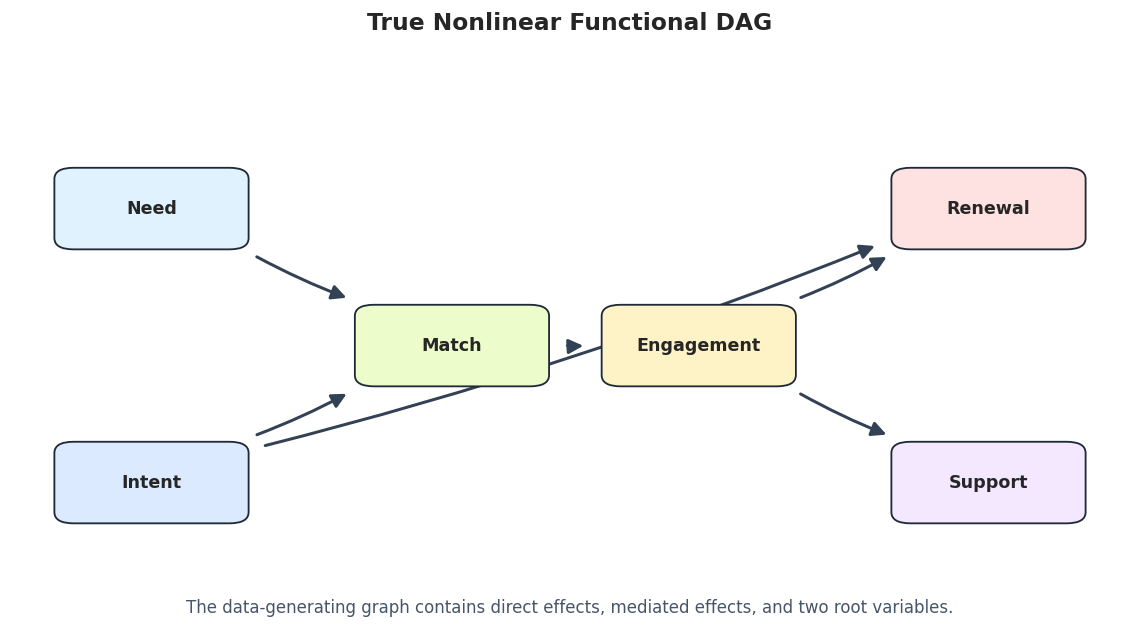

In [14]:
draw_box_graph(
    true_dag_edges,
    title="True Nonlinear Functional DAG",
    path=FIGURE_DIR / f"{NOTEBOOK_PREFIX}_true_nonlinear_dag.png",
    note="The data-generating graph contains direct effects, mediated effects, and two root variables.",
)

The graph is intentionally familiar from earlier tutorials but with nonlinear mechanisms. That lets us focus on how the method behaves rather than on decoding a new domain story.

## Pairwise ANM Screen Over The DAG Variables

This cell runs ANM on every pair of variables and records the preferred pairwise direction. This is not a complete causal discovery algorithm; it is a screening exercise that reveals which pairs have strong asymmetric functional signals.

In [15]:
pairwise_rows = []
for left, right in itertools.combinations(nonlinear_dag_df.columns, 2):
    result = run_anm_pair(nonlinear_dag_df[left], nonlinear_dag_df[right], x_name=left, y_name=right)
    pairwise_rows.append(result)

pairwise_screen = pd.DataFrame(pairwise_rows).sort_values("p_value_margin", ascending=False).reset_index(drop=True)
pairwise_screen["decision_label"] = pairwise_screen.apply(direction_label, axis=1)
pairwise_screen.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pairwise_dag_screen.csv", index=False)
display(pairwise_screen.round(6))

,x,y,p_value_x_to_y,p_value_y_to_x,preferred_direction,preferred_source,preferred_target,p_value_margin,elapsed_seconds,decision_label
0,match,renewal,0.942515,0.000228,match -> renewal,match,renewal,0.942287,0.161784,match -> renewal (margin=0.942)
1,match,support,0.922015,0.002367,match -> support,match,support,0.919648,0.165167,match -> support (margin=0.920)
2,need,support,0.914799,0.000212,need -> support,need,support,0.914587,0.193659,need -> support (margin=0.915)
3,need,renewal,0.871105,0.000003,need -> renewal,need,renewal,0.871102,0.163177,need -> renewal (margin=0.871)
4,need,match,0.790317,0.061176,need -> match,need,match,0.729141,0.148848,need -> match (margin=0.729)
5,engagement,renewal,0.607735,0.000000,engagement -> renewal,engagement,renewal,0.607735,0.183378,engagement -> renewal (margin=0.608)
6,intent,match,0.571377,0.057783,intent -> match,intent,match,0.513594,0.215442,intent -> match (margin=0.514)
7,renewal,support,0.552602,0.059120,renewal -> support,renewal,support,0.493481,0.141375,renewal -> support (margin=0.493)
8,match,engagement,0.553550,0.116493,match -> engagement,match,engagement,0.437057,0.153713,match -> engagement (margin=0.437)
9,intent,renewal,0.523018,0.095245,intent -> renewal,intent,renewal,0.427772,0.180074,intent -> renewal (margin=0.428)


The largest margins often include true direct edges, but they can also include indirect paths such as `need -> renewal`. This is the point: pairwise ANM can surface useful directional hints, but it does not know the multivariate adjustment set.

## Turn The Pairwise Screen Into A Candidate Graph

To visualize the screen, we keep only pairs with a p-value margin of at least `0.50`. This stricter threshold is for readability only; it should not be treated as a universal rule.

In [16]:
PAIRWISE_MARGIN_THRESHOLD = 0.50
pairwise_candidate_edges = edge_table_from_pairs(
    pairwise_screen,
    run_label="pairwise_anm_screen",
    min_margin=PAIRWISE_MARGIN_THRESHOLD,
)
pairwise_candidate_metrics = summarize_pairwise_screen(
    pairwise_candidate_edges,
    true_dag_edges,
    label="pairwise_anm_screen",
)

pairwise_candidate_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pairwise_candidate_edges.csv", index=False)
pairwise_candidate_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pairwise_candidate_metrics.csv", index=False)

display(pairwise_candidate_edges.round(6))
display(pairwise_candidate_metrics)

,run,source,edge_type,target,p_value_margin,p_value_x_to_y,p_value_y_to_x
0,pairwise_anm_screen,match,-->,renewal,0.942287,0.942515,0.000228
1,pairwise_anm_screen,match,-->,support,0.919648,0.922015,0.002367
2,pairwise_anm_screen,need,-->,support,0.914587,0.914799,0.000212
3,pairwise_anm_screen,need,-->,renewal,0.871102,0.871105,0.000003
4,pairwise_anm_screen,need,-->,match,0.729141,0.790317,0.061176
5,pairwise_anm_screen,engagement,-->,renewal,0.607735,0.607735,0.000000
6,pairwise_anm_screen,intent,-->,match,0.513594,0.571377,0.057783


,run,reported_edges,true_direct_edges,correct_direct_edges,reversed_true_edges,missing_true_adjacencies,indirect_or_extra_adjacencies
0,pairwise_anm_screen,7,6,3,0,3,4


The metrics intentionally count indirect or extra adjacencies. A pairwise screen may be directionally reasonable while still over-reporting edges because it cannot distinguish direct causation from mediated association.

## Draw The Pairwise ANM Candidate Graph

The candidate graph makes the over-reporting behavior visible. It should be read as a set of pairwise hints, not as a final learned DAG.

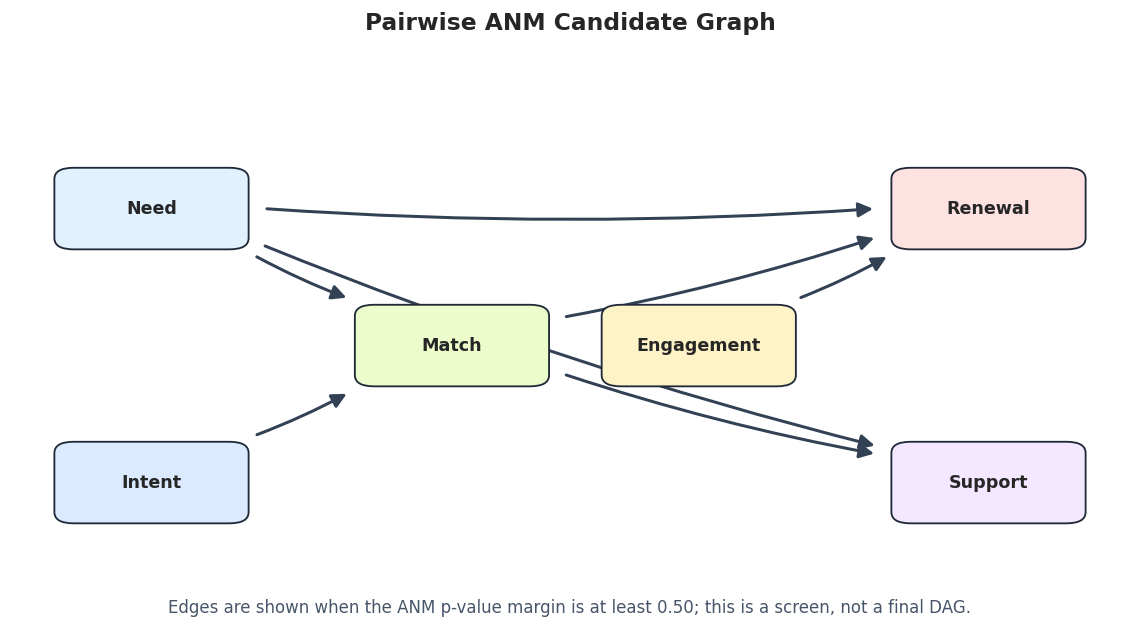

In [17]:
draw_box_graph(
    pairwise_candidate_edges,
    title="Pairwise ANM Candidate Graph",
    path=FIGURE_DIR / f"{NOTEBOOK_PREFIX}_pairwise_anm_candidate_graph.png",
    note=f"Edges are shown when the ANM p-value margin is at least {PAIRWISE_MARGIN_THRESHOLD:.2f}; this is a screen, not a final DAG.",
)

The plot should look busier than the true DAG. That is expected because pairwise testing sees strong marginal relationships even when the direct path runs through another variable.

## Direct Edge Versus Indirect Path Review

This cell labels each pairwise candidate as a true direct edge, a reversed direct edge, or an indirect/extra adjacency. This is the table a careful analyst would discuss before deciding which edges deserve further modeling.

In [18]:
true_directed = set(zip(true_dag_edges["source"], true_dag_edges["target"]))
true_reversed = {(target, source) for source, target in true_directed}

classification_rows = []
for row in pairwise_candidate_edges.itertuples(index=False):
    pair = (row.source, row.target)
    if pair in true_directed:
        classification = "true_direct_edge"
    elif pair in true_reversed:
        classification = "reversed_true_edge"
    else:
        classification = "indirect_or_extra_adjacency"
    classification_rows.append(
        {
            "source": row.source,
            "target": row.target,
            "p_value_margin": row.p_value_margin,
            "classification": classification,
        }
    )

candidate_classification = pd.DataFrame(classification_rows).sort_values(["classification", "source", "target"])
candidate_classification.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pairwise_candidate_classification.csv", index=False)
display(candidate_classification.round(6))

,source,target,p_value_margin,classification
0,match,renewal,0.942287,indirect_or_extra_adjacency
1,match,support,0.919648,indirect_or_extra_adjacency
3,need,renewal,0.871102,indirect_or_extra_adjacency
2,need,support,0.914587,indirect_or_extra_adjacency
5,engagement,renewal,0.607735,true_direct_edge
6,intent,match,0.513594,true_direct_edge
4,need,match,0.729141,true_direct_edge


The classification table is where the lesson lands. Pairwise ANM is excellent for asking, “Does this pair have a directional functional signal?” It is not sufficient for answering, “Is this pair a direct edge after accounting for the rest of the graph?”

## Reporting Checklist

A functional causal model report should include the mechanism assumptions and the diagnostics used to support them. This checklist records the minimum items that make an ANM or PNL analysis easier to audit.

In [19]:
reporting_checklist = pd.DataFrame(
    [
        {
            "item": "State the functional form assumption",
            "what_to_report": "Whether the analysis assumes ANM, PNL, or another functional causal model.",
            "why_it_matters": "The direction result is conditional on this mechanism class.",
        },
        {
            "item": "Show both direction tests",
            "what_to_report": "Forward and backward residual-independence p-values.",
            "why_it_matters": "The asymmetry is the evidence; a single p-value is not enough context.",
        },
        {
            "item": "Plot fitted functions and residuals",
            "what_to_report": "Scatter plots, fitted curves, and residuals versus proposed causes.",
            "why_it_matters": "Visual structure can reveal misspecification that a table hides.",
        },
        {
            "item": "Check stability",
            "what_to_report": "Bootstrap direction frequencies and p-value margins.",
            "why_it_matters": "Unstable directions should be reported as exploratory.",
        },
        {
            "item": "Separate pairwise hints from direct edges",
            "what_to_report": "Whether each candidate is direct, indirect, reversed, or unexplained by the known graph.",
            "why_it_matters": "Pairwise tests can over-report direct structure in multivariate systems.",
        },
        {
            "item": "Document optional dependencies",
            "what_to_report": "Whether PNL or neural functional models were actually runnable in the environment.",
            "why_it_matters": "Reproducibility requires knowing which parts were executed versus described.",
        },
    ]
)
reporting_checklist.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_functional_model_reporting_checklist.csv", index=False)
display(reporting_checklist)

,item,what_to_report,why_it_matters
0,State the functional form assumption,"Whether the analysis assumes ANM, PNL, or anot...",The direction result is conditional on this me...
1,Show both direction tests,Forward and backward residual-independence p-v...,The asymmetry is the evidence; a single p-valu...
2,Plot fitted functions and residuals,"Scatter plots, fitted curves, and residuals ve...",Visual structure can reveal misspecification t...
3,Check stability,Bootstrap direction frequencies and p-value ma...,Unstable directions should be reported as expl...
4,Separate pairwise hints from direct edges,"Whether each candidate is direct, indirect, re...",Pairwise tests can over-report direct structur...
5,Document optional dependencies,Whether PNL or neural functional models were a...,Reproducibility requires knowing which parts w...


The checklist keeps the analysis honest. Functional causal models are compelling when the assumptions are plausible and the diagnostics agree; they are fragile when the functional story is unexamined.

## Artifact Manifest

The final cell lists the datasets, tables, and figures produced by this notebook. This makes the tutorial outputs easy to find and review later.

In [20]:
artifact_rows = []
for folder, artifact_type in [(DATASET_DIR, "dataset"), (TABLE_DIR, "table"), (FIGURE_DIR, "figure")]:
    for artifact_path in sorted(folder.glob(f"{NOTEBOOK_PREFIX}_*")):
        artifact_rows.append(
            {
                "artifact_type": artifact_type,
                "path": str(artifact_path.relative_to(NOTEBOOK_DIR)),
                "size_kb": round(artifact_path.stat().st_size / 1024, 2),
            }
        )

artifact_manifest = pd.DataFrame(artifact_rows)
artifact_manifest.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_artifact_manifest.csv", index=False)
display(artifact_manifest)

,artifact_type,path,size_kb
0,dataset,outputs/datasets/11_nonlinear_dag_data.csv,34.68
1,dataset,outputs/datasets/11_pairwise_additive_noise.csv,11.37
2,dataset,outputs/datasets/11_pairwise_scenario_data.csv,135.39
3,table,outputs/tables/11_artifact_manifest.csv,1.49
4,table,outputs/tables/11_functional_model_concept_map...,0.97
5,table,outputs/tables/11_functional_model_reporting_c...,1.03
6,table,outputs/tables/11_package_versions.csv,0.13
7,table,outputs/tables/11_pairwise_anm_direction_resul...,0.23
8,table,outputs/tables/11_pairwise_bootstrap_results.csv,2.28
9,table,outputs/tables/11_pairwise_bootstrap_summary.csv,0.12


This notebook now gives a complete functional causal model tutorial: ANM/PNL theory, runnable pairwise ANM, residual diagnostics, bootstrap stability, scenario stress tests, optional PNL handling, multivariate pairwise screening, and reporting guidance.

The next tutorial can move to permutation-based discovery methods, where the search problem is framed as finding good variable orderings.